In [6]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.datasets import make_moons

from tqdm import tqdm

import FrEIA.framework as Ff
import FrEIA.modules as Fm
import FrEIA.modules.splines as Fms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Functions

In [7]:
def get_loss(model, x):
    z, ljd = model(x, rev=False) # pass through encoder

    ML_pz = 0.5*z**2 #prior is a standard normal

    ML = (ML_pz.sum(-1) - ljd).sum(0)
    
    loss = ML.sum() / x.numel()

    #loss is used for backpropagation
    #ML in losses_eval are used for evaluation during training

    losses_eval = {
        'ML': ML.sum() / x.numel(),
    }
    return loss, losses_eval

In [8]:
def train(model, data_function, optimizer, losses, kwargs_data, N_iter=1000, print_info=True):
    info_function = lambda x: x
    if print_info:
        info_function = lambda x: tqdm(x)

    for i in info_function(range(N_iter)):
        optimizer.zero_grad()
        x = torch.Tensor(data_function(kwargs_data['batch_size'])).to(device)
        x.requires_grad = True

        # Normalize data
        x = (x - kwargs_data['data_mean']) / kwargs_data['data_std']
        
        # Inflate manifold with normal noise
        x_noise = torch.randn_like(x)*kwargs_data['noise_sigma']
        x = x + x_noise

        loss, losses_eval = get_loss(model, x)

        ML = losses_eval['ML']
        
        loss.backward()
        losses['ML'] = np.append(losses['ML'], ML.cpu().detach().numpy())
        optimizer.step()

In [9]:
def INN_init(N_dim, N_blocks = 8, conditions = 0, act_func='relu', ch_hidden=None, bins=None, coupling_block = 'GLOW', clamp=2.0, permute_soft=False, permute_hard=True, householder_perms=2, use_actnorms=True, lr=1e-3, device=None):
    def subnet_fc(c_in, c_out, ch_hidden=128, act_func='relu', layers=3):
        if act_func == 'relu':
            act_func = nn.ReLU()
        elif act_func == 'tanh':
            act_func = nn.Tanh()
        else:
            act_func = nn.ReLU()
        subnet = nn.Sequential()
        subnet.append(nn.Linear(c_in, ch_hidden))
        subnet.append(act_func)
        for i in range(layers-2):
            subnet.append(nn.Linear(ch_hidden, ch_hidden))
            subnet.append(act_func)
        subnet.append(nn.Linear(ch_hidden,  c_out))
        subnet[-1].weight.data.zero_()
        subnet[-1].bias.data.zero_()
        return subnet

    if bins == None:
        bins = 10

    flow = Ff.SequenceINN(N_dim)

    subnet_fc_temp = lambda c_in, c_out: subnet_fc(c_in, c_out, act_func=act_func, ch_hidden=ch_hidden, layers=3)
    
    cond = None
    cond_shape = None
    try:
        if conditions > 0:
            cond = 0
            cond_shape = (conditions,)
    except:
        pass

    for k in range(N_blocks):
        if coupling_block == 'GLOW':
            flow.append(Fm.GLOWCouplingBlock, cond=cond, cond_shape=cond_shape, subnet_constructor=subnet_fc_temp, clamp=clamp)
        elif coupling_block == 'All':
            flow.append(Fm.AllInOneBlock, cond=cond, cond_shape=cond_shape, subnet_constructor=subnet_fc_temp, permute_soft=True)
        elif coupling_block == 'RQS':
            flow.append(Fms.RationalQuadraticSpline, cond=cond, cond_shape=cond_shape, bins=bins, subnet_constructor=subnet_fc_temp)
        elif coupling_block == 'GIN':
            flow.append(Fm.GINCouplingBlock, cond=cond, cond_shape=cond_shape, subnet_constructor=subnet_fc_temp)
        elif coupling_block == 'NICE':
            flow.append(Fm.NICECouplingBlock, cond=cond, cond_shape=cond_shape, subnet_constructor=subnet_fc_temp)
        else:
            raise ValueError('Incompatible coupling_block name')
        
        if permute_hard:
            flow.append(Fm.PermuteRandom)
        if permute_soft:
            flow.append(Fm.HouseholderPerm, n_reflections=householder_perms, fixed=True)
        if use_actnorms:
            flow.append(Fm.ActNorm)
    
    parameters = []
    for p in flow.parameters():
        parameters.append(p)

    optimizer_flow = torch.optim.Adam(parameters, lr=lr, weight_decay=1e-5) #torch.optim.SGD(parameters, lr=lr)
            
    flow = flow.to(device)
    losses = {
    'ML': []
    }
    return flow, optimizer_flow, losses

In [10]:
def plot_pdf(N_samples_manifold, resolution, model, show_original_manifold, show_pred_manifold, data_function=None, N_dim=2, x_range = [-3, 3], y_range = [-3, 3], c_range=None, figsize=6, plot_image=True, save_image=False, save_folder=None, info='', title='', fontsize=None, device=None, **kwargs):
    assert model != None, 'No model provided!'
    try:
        no_plot = kwargs['no_plot']
        fig, axes = kwargs['fig'], kwargs['axes']
    except:
        no_plot = False
    try:
        use_colorbar = kwargs['use_colorbar']
    except:
        use_colorbar = True

    #sample from grid in x-space
    x = torch.linspace(x_range[0], x_range[1], resolution)
    y = torch.linspace(y_range[0], y_range[1], resolution)
    x, y = torch.meshgrid(x, y)
    x = x.reshape(-1)
    y = y.reshape(-1)
    grid = torch.stack((x, y), 1)

    grid = grid.to(device)
    z_grid, ljd_grid = model(grid) #, return_jacs=False
    if ljd_grid.shape[0] == 1:
        ljd_grid = torch.ones_like(z_grid[:,0]) * ljd_grid
    ljd_grid = ljd_grid.reshape(resolution, resolution)


    pdf_z_grid = 1/np.sqrt(2*np.pi)**N_dim*torch.exp(-0.5*torch.sum(z_grid**2, 1))
    pdf_z_grid = pdf_z_grid.reshape(resolution, resolution)
    pdf_x_grid = pdf_z_grid*torch.exp(ljd_grid) #
    pdf_x_grid = pdf_x_grid.cpu().detach().numpy()

    try:
        constrained_layout = kwargs['constrained_layout']
    except:
        constrained_layout = False

    if not no_plot:
        fig, axes = plt.subplots(1, 1, figsize=(figsize, figsize), squeeze=False, constrained_layout=constrained_layout)
        axes = axes.flatten()

    #Plot PDF of x in x-space
    if c_range == None:
        c_range = [pdf_x_grid.min(), pdf_x_grid.max()]
    
    if kwargs['N_contours'] == None:
        im = axes[0].imshow(pdf_x_grid.T, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], origin='lower', cmap='viridis', vmin=c_range[0], vmax=c_range[1])
    #plot contourf
    else:
        im = axes[0].contourf(x.reshape(resolution, resolution).T, y.reshape(resolution, resolution).T, pdf_x_grid.T, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], levels=kwargs['N_contours'], cmap='viridis', vmin=c_range[0], vmax=c_range[1], antialiased=False)
    
    if use_colorbar:
        divider = make_axes_locatable(axes[0])
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(im, cax=cax, orientation='vertical')
    #axes[0].set_xlabel('x')
    #axes[0].set_ylabel('y')
    #axes[0].set_title(f'PDF in x-space, {title}')
    axes[0].set_title(title, fontsize=fontsize)

    if show_original_manifold:
        assert data_function != None, 'No data function provided!'
        samples_man = data_function(N_samples_manifold)
        axes[0].scatter(samples_man[:, 0], samples_man[:, 1], s=1, color='yellow', alpha=0.5, label='Original manifold')
    
    if show_pred_manifold:
        z = torch.randn(N_samples_manifold, 2).to(device)
        z[:, 1] = 0
        samples, _ = model(z, rev=True)
        samples = samples.cpu().detach().numpy()
        axes[0].scatter(samples[:, 0], samples[:, 1], s=1, color='red', alpha=0.5, label='Predicted manifold')
    
    axes[0].set_xlim(x_range)
    axes[0].set_ylim(y_range)

    try:
        dpi = kwargs['dpi']
    except:
        dpi = 200
    try:
        axis_off = kwargs['axis_off']
    except:
        axis_off = False
    try:
        output_filetype = kwargs['output_filetype']
    except:
        output_filetype = 'png'
    
    if axis_off:
        axes[0].axis('off')
    
    if not no_plot:
        if save_image:
            assert save_folder is not None
            plt.savefig(os.path.join(save_folder, 'pdf '+info+'.'+output_filetype), transparent=True, dpi=200, bbox_inches='tight')
        if plot_image:
            plt.show()
        plt.close(fig)

## Init

In [11]:
flow, optimizer_flow, losses = INN_init(N_dim = 2, N_blocks = 8, coupling_block = 'GLOW', ch_hidden=128, lr=1e-3, device=device)

In [12]:
kwargs_data = {
    'batch_size': 1024,
    'noise_sigma': 0.1, #standard deviation of the normal noise added to the data
    'N_dim': 2,
    'device': device,
    'dtype': torch.float32,
    'get_data' : None,
    'data_mean': torch.tensor([0., 0.]).to(device),
    'data_std': torch.tensor([1., 1.]).to(device),
}

## Training

In [13]:
data_function = (lambda batchsize: make_moons(n_samples=batchsize, noise=0)[0])
train(flow, data_function, optimizer_flow, losses, kwargs_data, N_iter=1000)

100%|██████████| 1000/1000 [01:01<00:00, 16.38it/s]


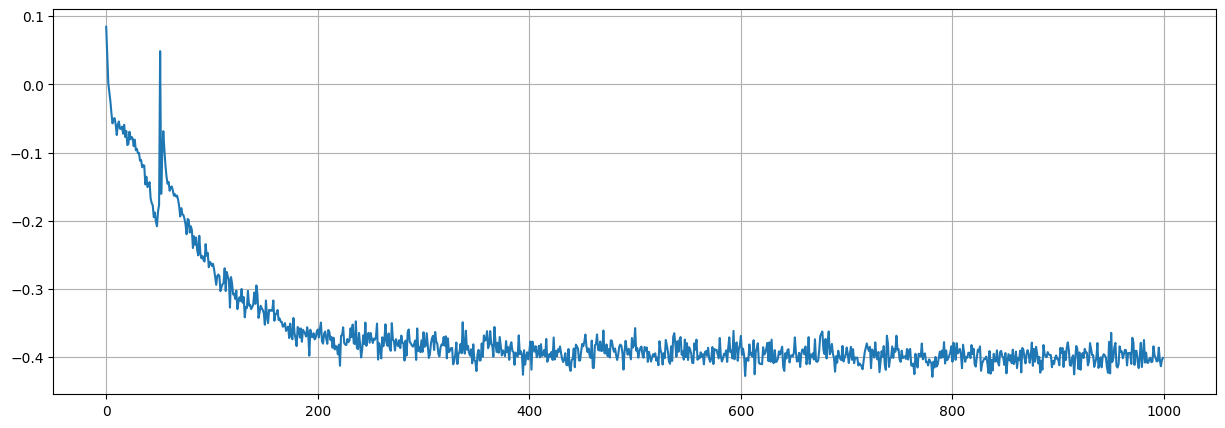

In [15]:
#plot loss
plt.figure(figsize=(15, 5))

plt.plot(losses['ML'])
plt.grid()
plt.show()

## Generate Samples

In [15]:
x_range = [-1.5, 2.5]
y_range = [-1, 1.5]

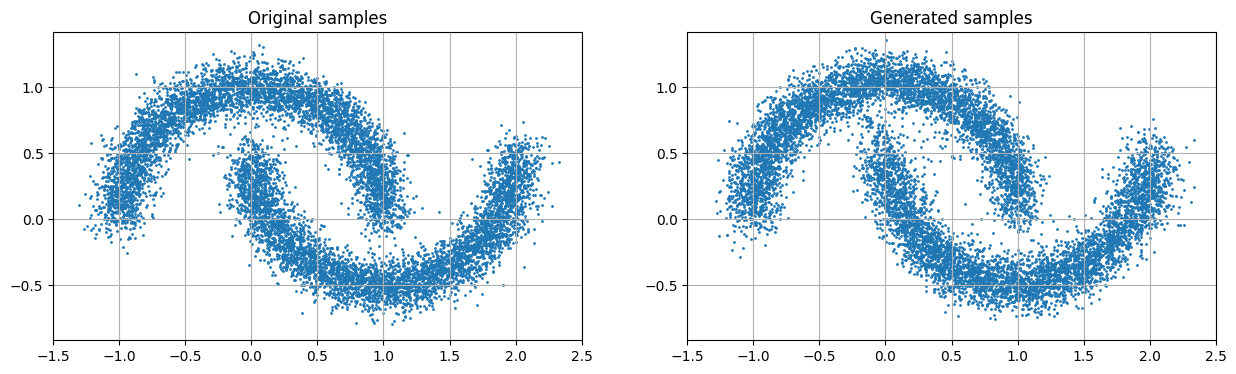

In [16]:
N_samples = 10000

#plot original samples
x = torch.Tensor(make_moons(n_samples=N_samples, noise=0)[0]).to(device)
x = x + torch.randn_like(x)*kwargs_data['noise_sigma']

plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.title('Original samples')
plt.scatter(x.cpu().detach().numpy()[:,0], x.cpu().detach().numpy()[:,1], s=1)
plt.grid()
plt.axis('equal')
plt.xlim(x_range)
plt.ylim(y_range)

#plot generated samples 
z = torch.randn(N_samples, 2).to(device)
x, _ = flow(z, rev=True)
#renormalize
x = x*kwargs_data['data_std'] + kwargs_data['data_mean']
x = x.cpu().detach().numpy()

plt.subplot(1,2,2)
plt.title('Generated samples')
plt.scatter(x[:, 0], x[:, 1], s=1)
plt.grid()
plt.axis('equal')
plt.xlim(x_range)
plt.ylim(y_range)

plt.show()

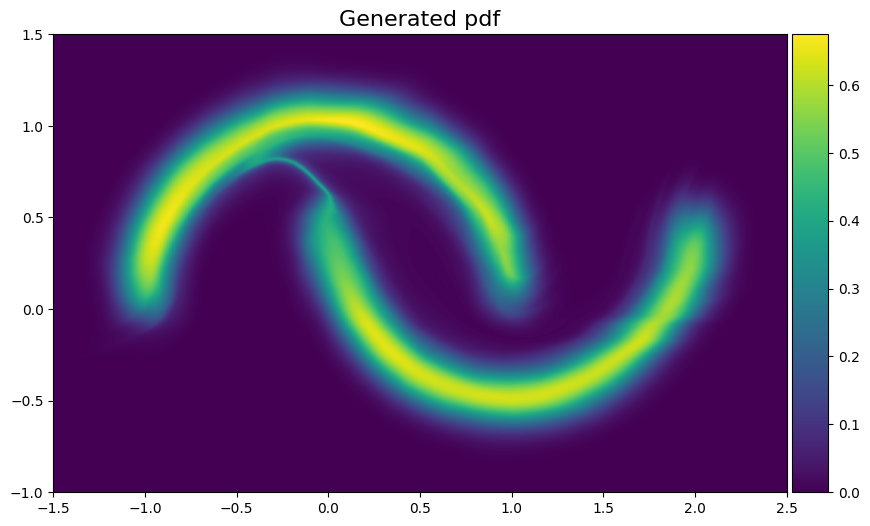

In [18]:
figsize = 10
samples_size = 0.5
linewidth = 1
manifold_size = 5
N_samples = 1000
N_manifold_samples = 10000
#data_function = lambda N_samples_manifold: make_moons(n_samples=N_samples_manifold, noise=0)[0]

fig, axes = plt.subplots(1, 1, figsize=(figsize, figsize), squeeze=False, constrained_layout=False)
axes = axes.flatten()

plot_pdf(N_samples_manifold=N_manifold_samples, resolution=500, model=flow, show_original_manifold=False, show_pred_manifold=False, data_function=data_function, N_dim=2, x_range=x_range, y_range=y_range, c_range=None, figsize=figsize, plot_image=True, save_image=False, save_folder=None, info=None, title='Generated pdf', fontsize=16, device=device, N_contours = None, no_plot=True, fig=fig, axes=axes, use_colorbar=True, constrained_layout=False, axis_off=False, output_filetype=False)

plt.show()